# Diabetes classification — Pima Indians Diabetes Dataset

Goal: predict `Outcome` (1 = diabetes, 0 = no diabetes) from 8 clinical measurements.

Workflow:
1. Load and explore the data
2. Treat physiologically impossible zeros as missing values
3. Stratified train/test split
4. Compare several classifiers with cross-validation
5. Tune the best model and choose a decision threshold
6. Evaluate on the held-out test set
7. Save the final model

In [63]:
# Core libraries: numerics, dataframes, plotting, and model persistence
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# scikit-learn: data splitting, cross-validation and hyperparameter search
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, cross_val_predict
# Building blocks for chaining preprocessing + model into one estimator
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
# Candidate classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# Evaluation metrics and plots
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, RocCurveDisplay, accuracy_score, f1_score,
                             precision_recall_curve, recall_score, precision_score)
from sklearn.inspection import permutation_importance

# Fixed seed so splits, CV folds and models are reproducible between runs
randomState = 42
sns.set_theme(style="whitegrid")

## 1. Load and explore

In [64]:
# Load the dataset: 768 patients, 8 features + the target column "Outcome"
df = pd.read_csv("data/diabetes.csv")
# Summary statistics per column (transposed so each feature is a row).
# Note the min of 0 in Glucose, BloodPressure, etc. -- these are impossible values.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


Outcome
0    0.651042
1    0.348958
Name: share, dtype: float64


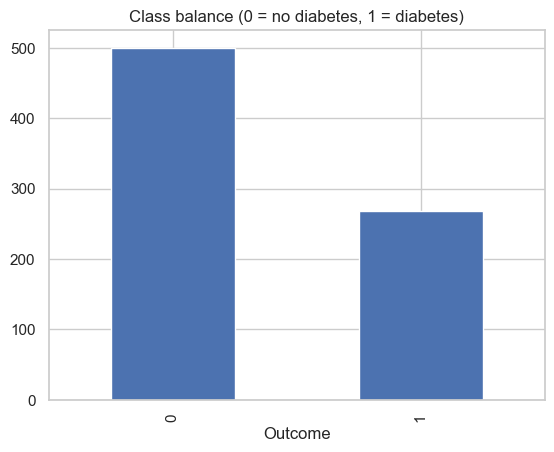

In [65]:
# Check class balance: about 65% non-diabetic vs 35% diabetic,
# which is why we stratify the split and use class weighting later
print(df["Outcome"].value_counts(normalize=True).rename("share"))
df["Outcome"].value_counts().plot(kind="bar", title="Class balance (0 = no diabetes, 1 = diabetes)");

### Zeros that are really missing values
A value of 0 is impossible for Glucose, BloodPressure, SkinThickness, Insulin, and BMI, so those zeros are recorded missing values. (Zeros in `Pregnancies` are valid.)

In [66]:
# Columns where 0 cannot be a real measurement and should be treated as missing
zeroAsMissing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
# Count how many zeros (i.e. missing values) each of these columns has
(df[zeroAsMissing] == 0).sum().rename("zero count")

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
Name: zero count, dtype: int64

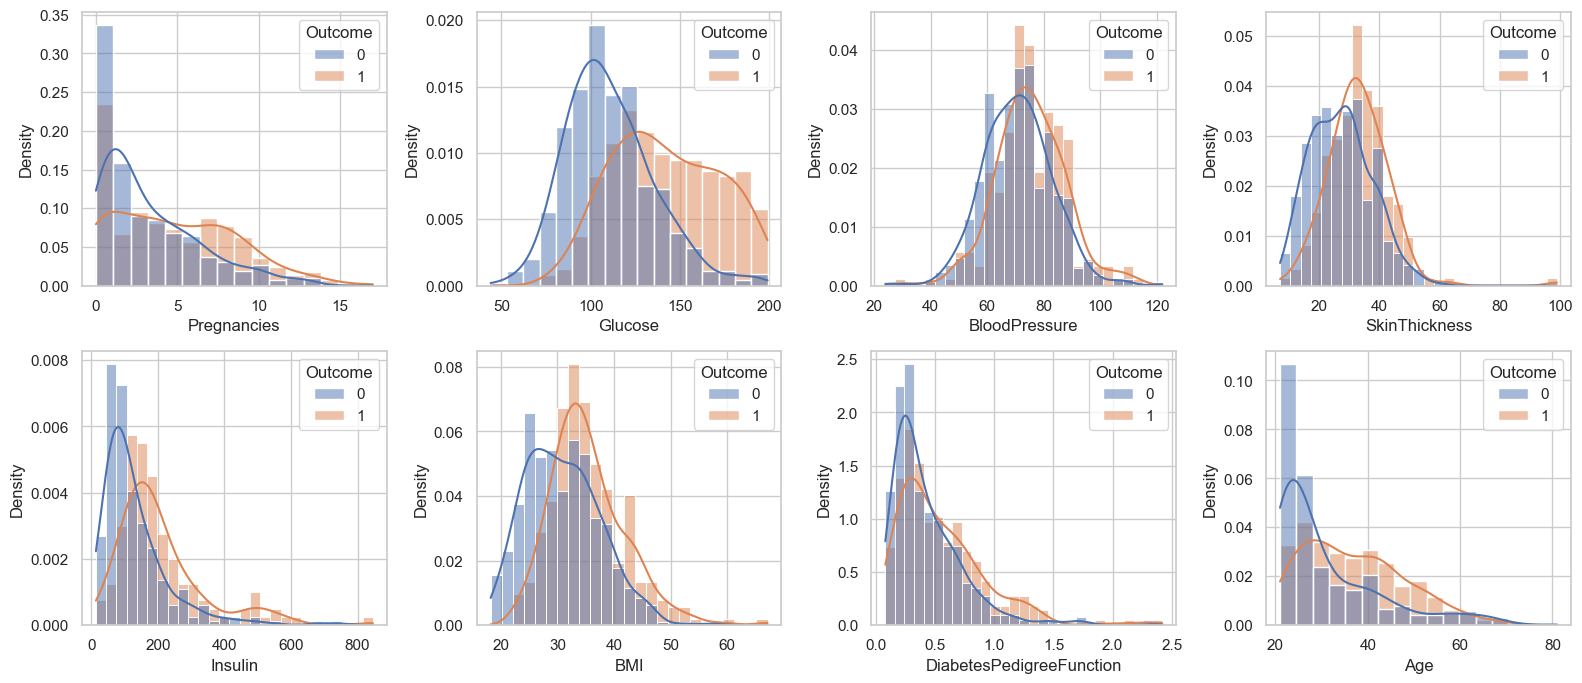

In [67]:
# Copy used only for plotting: replace the fake zeros with NaN so they don't distort the distributions
dfPlot = df.copy()
dfPlot[zeroAsMissing] = dfPlot[zeroAsMissing].replace(0, np.nan)

# One histogram per feature (2x4 grid), split by Outcome.
# common_norm=False normalises each class separately so the shapes are comparable
# despite the class imbalance.
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, df.columns[:-1]):  # all columns except Outcome
    sns.histplot(data=dfPlot, x=col, hue="Outcome", kde=True, ax=ax, stat="density", common_norm=False)
plt.tight_layout()

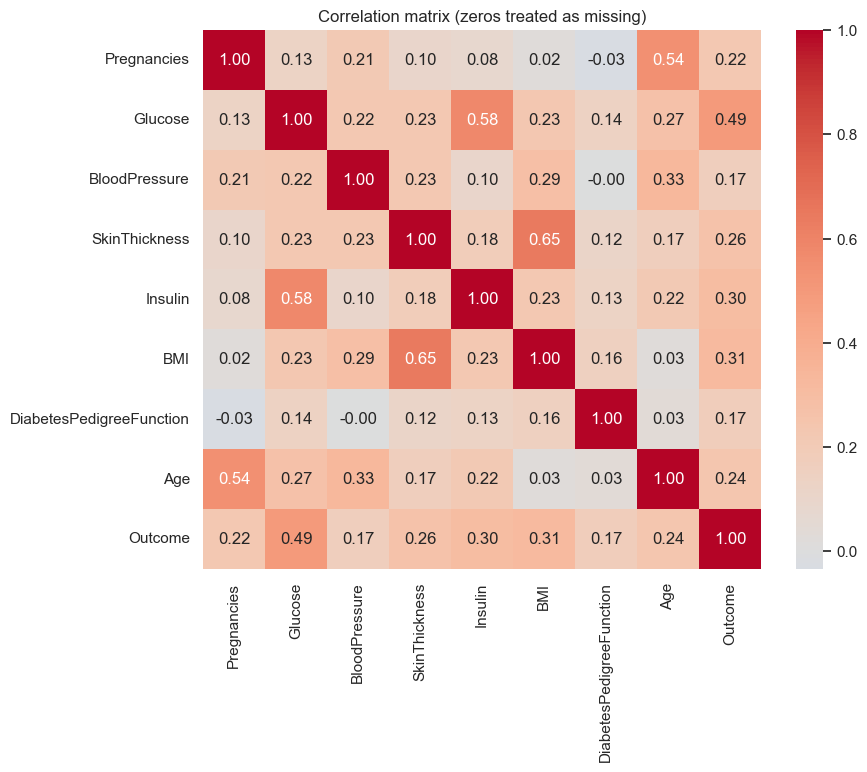

In [68]:
# Pairwise Pearson correlations between all columns (including Outcome).
# NaNs are ignored pairwise, so the fake zeros don't affect the result.
plt.figure(figsize=(9, 7))
sns.heatmap(dfPlot.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix (zeros treated as missing)");

## 2. Train/test split
The split is stratified to keep the 65/35 class ratio. All preprocessing happens inside a pipeline so it is fitted on training data only, which prevents leakage into the test set.

In [69]:
# Separate features (X) from the target (y)
x = df.drop(columns="Outcome")
y = df["Outcome"]

# Hold out 20% as a test set. stratify=y keeps the same class ratio in both parts.
xTrain, xTest, yTrain, yTest = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=randomState)
print(xTrain.shape, xTest.shape)

(614, 8) (154, 8)


## 3. Preprocessing pipeline
- In the five affected columns, treat 0 as missing and impute it with the training-set median
- Standardize features (needed for LogReg, KNN, and SVM; harmless for trees)

In [70]:
# Preprocessing steps, fitted on training data only (inside each CV fold as well)
preprocess = Pipeline([
    # Step 1: in the zeroAsMissing columns, replace 0 with the column median.
    # remainder="passthrough" keeps the other columns (Pregnancies, DPF, Age) unchanged.
    # Note: ColumnTransformer outputs the imputed columns first, then the passthrough ones.
    ("impute", ColumnTransformer(
        [("zero_as_missing", SimpleImputer(missing_values=0, strategy="median"), zeroAsMissing)],
        remainder="passthrough")),
    # Step 2: scale every feature to mean 0 and standard deviation 1
    ("scale", StandardScaler()),
])

def makePipeline(model):
    """Wrap a classifier with the shared preprocessing so they are fitted together."""
    return Pipeline([("prep", preprocess), ("model", model)])

## 4. Compare models with 5-fold cross-validation
`class_weight="balanced"` is used where available to offset the class imbalance, which improves recall on the diabetic class.

In [71]:
# Candidate models with reasonable default settings.
# class_weight="balanced" gives the minority class (diabetes) more weight during training.
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "SVM (RBF)": SVC(probability=True, class_weight="balanced", random_state=randomState),  # probability=True enables predict_proba (needed for ROC AUC)
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=randomState),
    "Gradient Boosting": GradientBoostingClassifier(random_state=randomState),
}

# 5-fold CV where every fold keeps the original class ratio
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=randomState)
scoring = ["accuracy", "f1", "recall", "roc_auc"]

rows = []
for name, model in models.items():
    # Train and score the full pipeline on each of the 5 folds (training data only)
    s = cross_validate(makePipeline(model), xTrain, yTrain, cv=cv, scoring=scoring)
    # Average each metric over the folds; also keep the ROC AUC spread to judge stability
    rows.append({"model": name, **{m: s[f"test_{m}"].mean() for m in scoring},
                 "roc_auc_std": s["test_roc_auc"].std()})

# Results table, best ROC AUC first
cvResults = pd.DataFrame(rows).set_index("model").sort_values("roc_auc", ascending=False)
cvResults.round(3)

,accuracy,f1,recall,roc_auc,roc_auc_std
model,,,,,
Logistic Regression,0.762,0.672,0.701,0.844,0.016
SVM (RBF),0.761,0.690,0.762,0.837,0.031
KNN,0.769,0.632,0.571,0.832,0.030
Random Forest,0.765,0.632,0.575,0.824,0.028
Gradient Boosting,0.749,0.623,0.593,0.821,0.020


## 5. Hyperparameter tuning
We tune Logistic Regression, SVM, and Random Forest with a grid search, optimising ROC AUC, and keep the best one.

In [72]:
# Hyperparameter grids per model. The "model__" prefix targets the "model" step of the pipeline.
searchSpaces = {
    # C = inverse regularisation strength (smaller C = stronger regularisation)
    "Logistic Regression": (models["Logistic Regression"], {"model__C": [0.01, 0.1, 1, 10]}),
    # gamma = how far the influence of a single training point reaches in the RBF kernel
    "SVM (RBF)": (models["SVM (RBF)"], {"model__C": [0.1, 1, 10], "model__gamma": ["scale", 0.01, 0.1]}),
    # Limit tree depth / leaf size / features per split to reduce overfitting
    "Random Forest": (models["Random Forest"], {"model__max_depth": [None, 5, 8],
                                               "model__min_samples_leaf": [1, 3, 5],
                                               "model__max_features": ["sqrt", 0.5]}),
}

searches = {}
for name, (model, grid) in searchSpaces.items():
    # Try every combination in the grid with the same 5-fold CV; n_jobs=-1 uses all CPU cores
    gs = GridSearchCV(makePipeline(model), grid, cv=cv, scoring="roc_auc", n_jobs=-1)
    gs.fit(xTrain, yTrain)
    searches[name] = gs
    print(f"{name:20s} best CV ROC AUC = {gs.best_score_:.3f}  params = {gs.best_params_}")

# Pick the model with the highest CV ROC AUC. best_estimator_ is already refitted on all of XTrain.
bestName = max(searches, key=lambda n: searches[n].best_score_)
bestModel = searches[bestName].best_estimator_
print(f"\nSelected model: {bestName}")

Logistic Regression  best CV ROC AUC = 0.845  params = {'model__C': 0.1}
SVM (RBF)            best CV ROC AUC = 0.849  params = {'model__C': 1, 'model__gamma': 0.01}
Random Forest        best CV ROC AUC = 0.840  params = {'model__max_depth': 5, 'model__max_features': 0.5, 'model__min_samples_leaf': 5}

Selected model: SVM (RBF)


## 5b. Choose the decision threshold
By default a patient is classified as diabetic when the predicted probability is ≥ 0.5. For screening, missing a diabetic patient (false negative) is worse than a false alarm, so we lower the threshold until recall reaches a target.

The threshold is chosen from out-of-fold cross-validation predictions on the **training set**, so the test set stays untouched until the final evaluation.

Chosen threshold: 0.247
CV recall    at 0.5: 0.589   at 0.247: 0.850
CV precision at 0.5: 0.728   at 0.247: 0.563


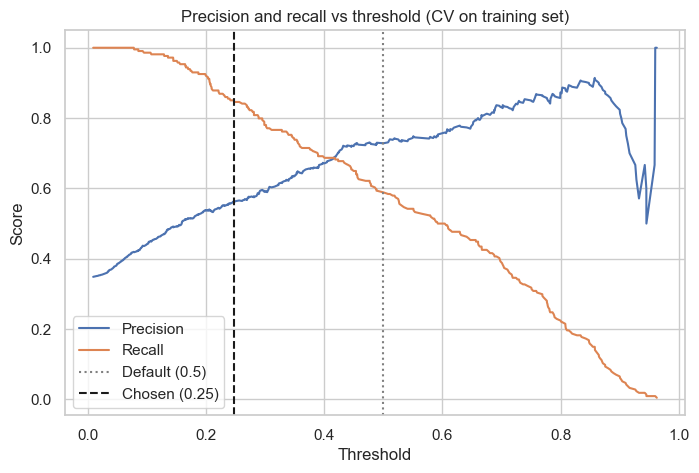

In [73]:
# Minimum share of diabetic patients we want to catch
targetRecall = 0.85

# Out-of-fold probabilities: each training patient is scored by a model that never saw them
cvProb = cross_val_predict(bestModel, xTrain, yTrain, cv=cv, method="predict_proba")[:, 1]

# Precision and recall for every possible threshold.
# precision/recall have one more element than thresholds, so drop the last one to align them.
precision, recall, thresholds = precision_recall_curve(yTrain, cvProb)
precision, recall = precision[:-1], recall[:-1]

# Highest threshold that still reaches the target recall (highest = fewest false alarms)
threshold = thresholds[recall >= targetRecall].max()
cvPred = (cvProb >= threshold).astype(int)
print(f"Chosen threshold: {threshold:.3f}")
print(f"CV recall    at 0.5: {recall_score(yTrain, cvProb >= 0.5):.3f}   at {threshold:.3f}: {recall_score(yTrain, cvPred):.3f}")
print(f"CV precision at 0.5: {precision_score(yTrain, cvProb >= 0.5):.3f}   at {threshold:.3f}: {precision_score(yTrain, cvPred):.3f}")

# Precision and recall as a function of the threshold
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision, label="Precision")
plt.plot(thresholds, recall, label="Recall")
plt.axvline(0.5, color="grey", ls=":", label="Default (0.5)")
plt.axvline(threshold, color="k", ls="--", label=f"Chosen ({threshold:.2f})")
plt.xlabel("Threshold"); plt.ylabel("Score"); plt.legend()
plt.title("Precision and recall vs threshold (CV on training set)");

## 6. Evaluate on the held-out test set

In [74]:
# First and only use of the test set: probabilities, then hard predictions at the chosen threshold
yProb = bestModel.predict_proba(xTest)[:, 1]  # probability of class 1 (diabetes)
yPred = (yProb >= threshold).astype(int)

print(f"ROC AUC  : {roc_auc_score(yTest, yProb):.3f}\n")  # uses probabilities, independent of the threshold
for name, t in [("default", 0.5), ("chosen", threshold)]:
    pred = (yProb >= t).astype(int)
    print(f"Threshold {t:.3f} ({name}): accuracy {accuracy_score(yTest, pred):.3f}, "
          f"F1 {f1_score(yTest, pred):.3f}, recall {recall_score(yTest, pred):.3f}, "
          f"precision {precision_score(yTest, pred):.3f}")

# Precision, recall and F1 per class at the chosen threshold
print(f"\nClassification report at threshold {threshold:.3f}:")
print(classification_report(yTest, yPred, target_names=["No diabetes", "Diabetes"]))

ROC AUC  : 0.810

Threshold 0.500 (default): accuracy 0.708, F1 0.545, recall 0.500, precision 0.600
Threshold 0.247 (chosen): accuracy 0.701, F1 0.662, recall 0.833, precision 0.549

Classification report at threshold 0.247:
              precision    recall  f1-score   support

 No diabetes       0.88      0.63      0.73       100
    Diabetes       0.55      0.83      0.66        54

    accuracy                           0.70       154
   macro avg       0.71      0.73      0.70       154
weighted avg       0.76      0.70      0.71       154



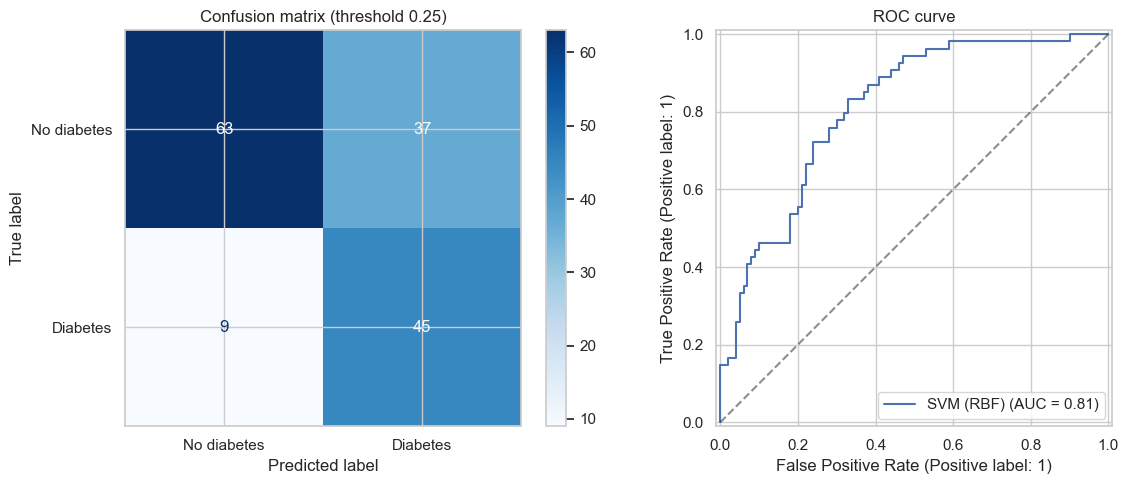

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Left: confusion matrix (rows = true class, columns = predicted class)
ConfusionMatrixDisplay.from_predictions(yTest, yPred, display_labels=["No diabetes", "Diabetes"],
                                        cmap="Blues", ax=axes[0])
axes[0].set_title(f"Confusion matrix (threshold {threshold:.2f})")
# Right: ROC curve, true positive rate vs false positive rate over all thresholds
RocCurveDisplay.from_predictions(yTest, yProb, ax=axes[1], name=bestName)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)  # diagonal = random guessing (AUC 0.5)
axes[1].set_title("ROC curve")
plt.tight_layout()

### Feature importance
Permutation importance on the test set: how much ROC AUC drops when a feature is shuffled. It works for any model type.

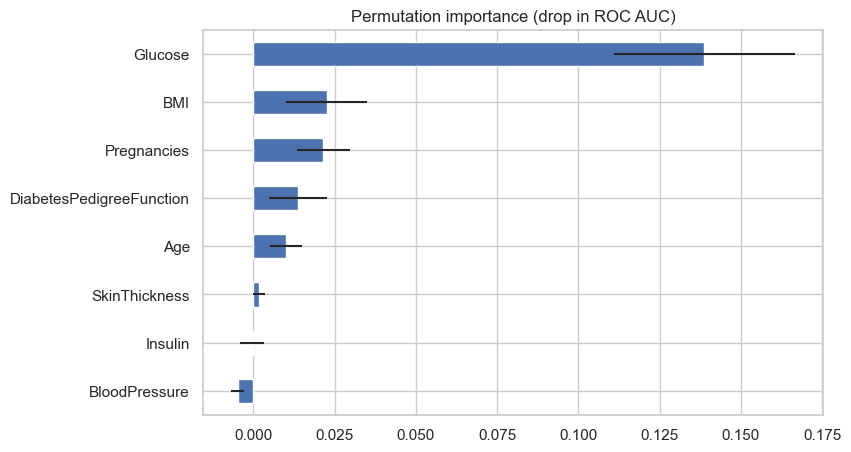

In [76]:
# Shuffle each feature 30 times and measure the average drop in test ROC AUC.
# A large drop means the model relies heavily on that feature.
perm = permutation_importance(bestModel, xTest, yTest, scoring="roc_auc",
                              n_repeats=30, random_state=randomState)
imp = pd.Series(perm.importances_mean, index=x.columns).sort_values()
# Horizontal bar chart; error bars are the std over the 30 repeats,
# reordered to match the sorted features
imp.plot(kind="barh", xerr=perm.importances_std[imp.index.map(list(x.columns).index)],
         title="Permutation importance (drop in ROC AUC)", figsize=(8, 5));

## 7. Save the model

In [77]:
# Save the whole pipeline (preprocessing + model) together with the chosen threshold
joblib.dump({"model": bestModel, "threshold": threshold}, "diabetes_model.joblib");